# Instrucciones
Realice un análisis exploratorio y visual con la librería Seaborn o Matplotlib, para encontrar los insights más importantes a su juicio.
1. Un notebook ordenado, documentado y reproducible con su análisis
2. Una infografica en donde presente los 3 principales insights encontrados (Considere que esta infografia será presentada a toda la organización)

Para realizar la infografia, se sugiere utilizar Canva, con su cuenta Google. La web de Canva es: http://www.canva.com/

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Calidad de figuras en notebook
plt.rcParams["figure.dpi"] = 120

# Estilo global (Seaborn ajusta Matplotlib)
sns.set_theme(style="whitegrid")

# Para ver todas las columnas en DataFrames
pd.set_option("display.max_columns", None)

## Lectura y wrangling inicial

In [2]:
# lectura con parseo de fechas
df = pd.read_csv('Superstore.csv', encoding='windows-1252', parse_dates=['Order Date','Ship Date'])

In [3]:
df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2014-110422,2014-01-21,2014-01-23,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,Florida,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028
9990,9991,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332
9991,9992,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932
9992,9993,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200


In [4]:
# eliminamos columnas que no serán de utilidad
df.drop(['Row ID', 'Postal Code'], axis=1, inplace=True)

In [5]:
# estructura del dataframe
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order ID       9994 non-null   str           
 1   Order Date     9994 non-null   datetime64[us]
 2   Ship Date      9994 non-null   datetime64[us]
 3   Ship Mode      9994 non-null   str           
 4   Customer ID    9994 non-null   str           
 5   Customer Name  9994 non-null   str           
 6   Segment        9994 non-null   str           
 7   Country        9994 non-null   str           
 8   City           9994 non-null   str           
 9   State          9994 non-null   str           
 10  Region         9994 non-null   str           
 11  Product ID     9994 non-null   str           
 12  Category       9994 non-null   str           
 13  Sub-Category   9994 non-null   str           
 14  Product Name   9994 non-null   str           
 15  Sales          9994 non-null   f

In [6]:
# algunos registros de ejemplo
df.sample(4).T

,2404,9226,4913,5742
Order ID,CA-2017-108574,CA-2017-121160,CA-2017-127306,US-2017-147886
Order Date,2017-10-07 00:00:00,2017-11-04 00:00:00,2017-01-14 00:00:00,2017-03-28 00:00:00
Ship Date,2017-10-11 00:00:00,2017-11-04 00:00:00,2017-01-18 00:00:00,2017-03-31 00:00:00
Ship Mode,Standard Class,Same Day,Standard Class,First Class
Customer ID,MG-18145,FM-14290,BH-11710,DH-13075
Customer Name,Mike Gockenbach,Frank Merwin,Brosina Hoffman,Dave Hallsten
Segment,Consumer,Home Office,Consumer,Corporate
Country,United States,United States,United States,United States
City,Los Angeles,Bryan,Johnson City,Fairfield
State,California,Texas,Tennessee,California


In [7]:
print("Valores nulos por columna:")
print(df.isnull().sum())

print("Duplicados:", df.duplicated().sum())


Valores nulos por columna:
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64
Duplicados: 1


In [8]:
df.describe()

,Order Date,Ship Date,Sales,Quantity,Discount,Profit
count,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000
mean,2016-04-30 00:07:12.259355,2016-05-03 23:06:58.571142,229.858001,3.789574,0.156203,28.656896
min,2014-01-03 00:00:00,2014-01-07 00:00:00,0.444000,1.000000,0.000000,-6599.978000
25%,2015-05-23 00:00:00,2015-05-27 00:00:00,17.280000,2.000000,0.000000,1.728750
50%,2016-06-26 00:00:00,2016-06-29 00:00:00,54.490000,3.000000,0.200000,8.666500
75%,2017-05-14 00:00:00,2017-05-18 00:00:00,209.940000,5.000000,0.200000,29.364000
max,2017-12-30 00:00:00,2018-01-05 00:00:00,22638.480000,14.000000,0.800000,8399.976000
std,NaN,NaN,623.245101,2.225110,0.206452,234.260108


## Análisis Visual

### Ventas mensuales por año

In [10]:
# Crear columnas auxiliares desde Order Date
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['DayOfWeek'] = df['Order Date'].dt.day_name()

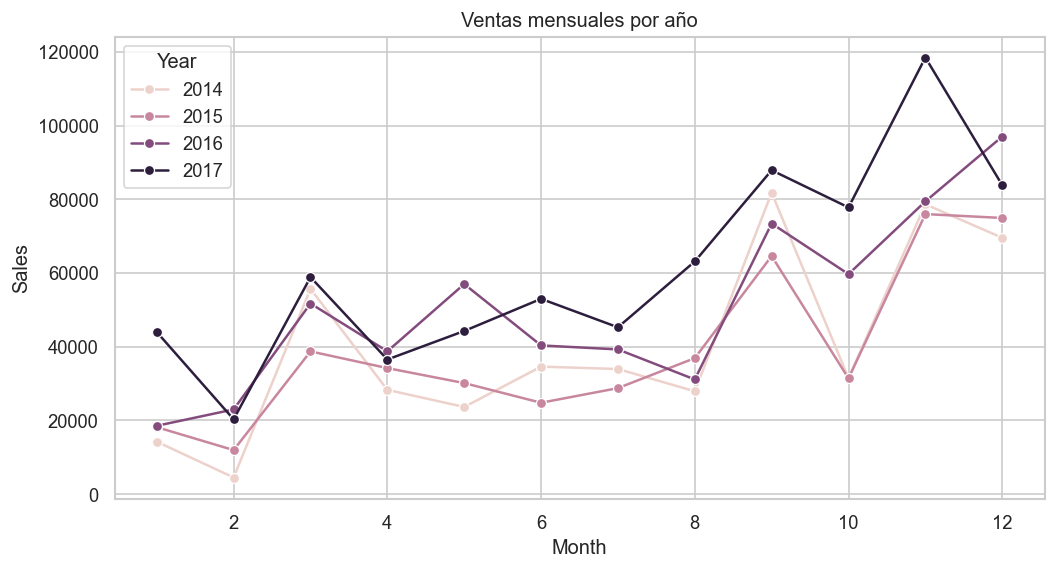

In [12]:
# Agrupación por año y mes
sales_by_month = df.groupby(['Year','Month'])['Sales'].sum().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(data=sales_by_month, x='Month', y='Sales', hue='Year', marker="o")
plt.title("Ventas mensuales por año")
plt.show()


### Segmentos

C:\Users\ccarr\AppData\Local\Temp\ipykernel_17488\2476686108.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Segment', y='Sales', estimator=sum, palette="viridis", errorbar=None)


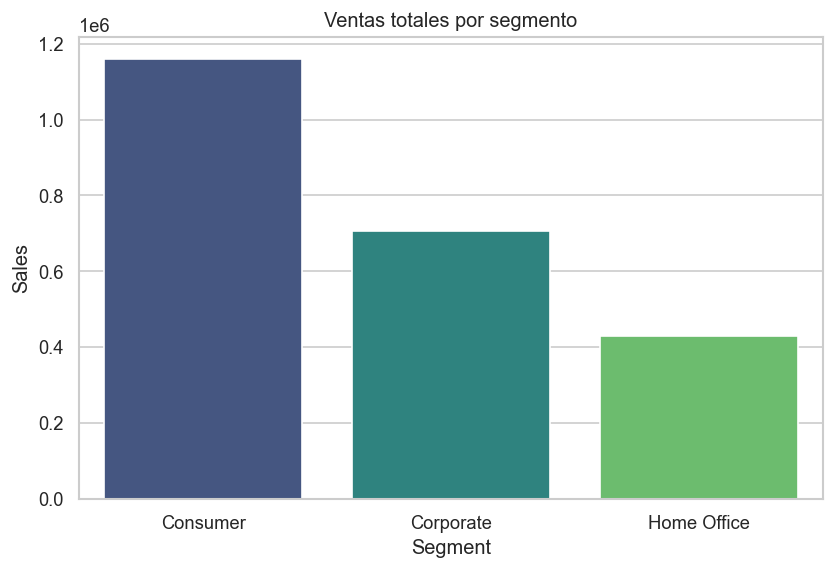

In [15]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x='Segment', y='Sales', estimator=sum, palette="viridis", errorbar=None)
plt.title("Ventas totales por segmento")
plt.show()

C:\Users\ccarr\AppData\Local\Temp\ipykernel_17488\3735938343.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Segment', y='Profit', estimator=sum, palette="magma", errorbar=None)


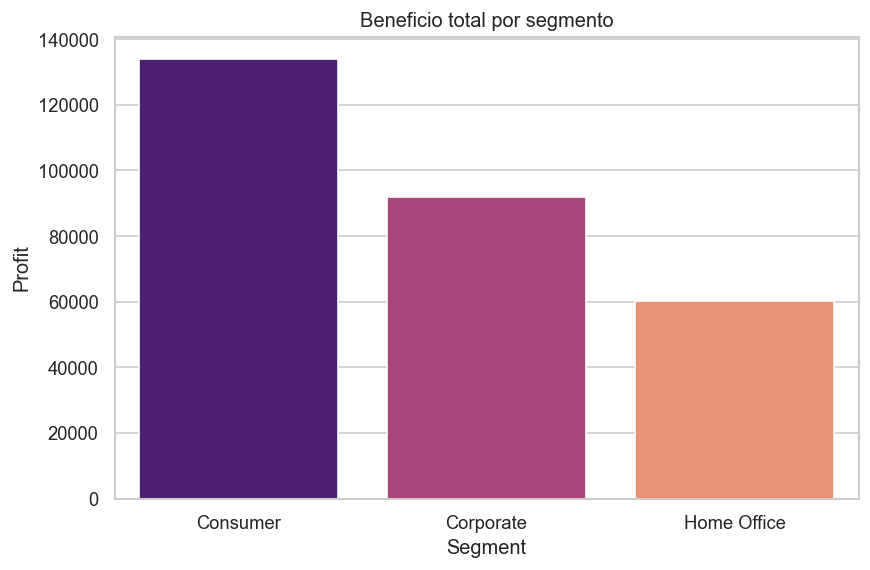

In [16]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x='Segment', y='Profit', estimator=sum, palette="magma", errorbar=None)
plt.title("Beneficio total por segmento")
plt.show()

### Descuento y Ganancia

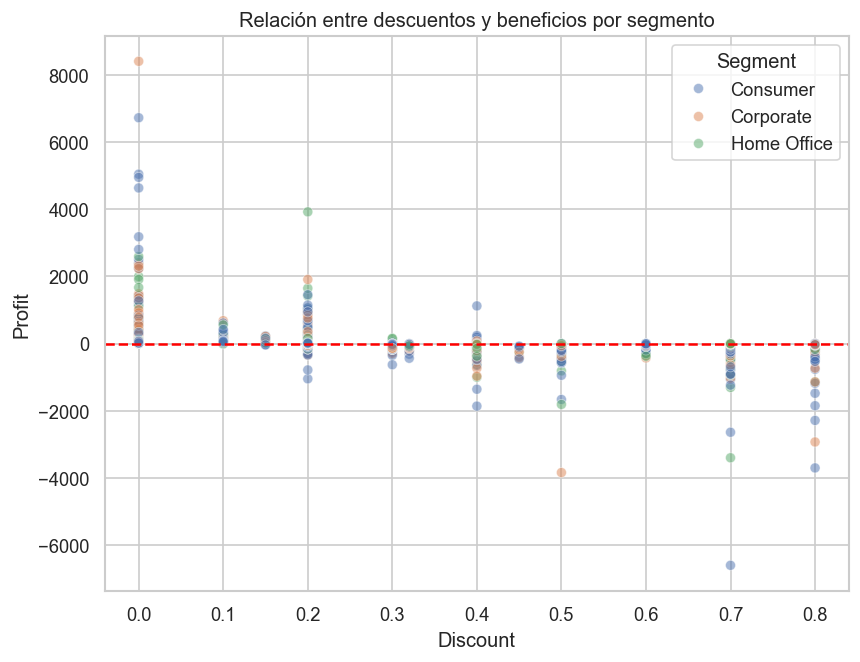

In [17]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='Discount', y='Profit', alpha=0.5, hue='Segment')
plt.title("Relación entre descuentos y beneficios por segmento")
plt.axhline(0, color='red', linestyle='--')  # línea de referencia en beneficio 0
plt.show()